In [2]:
import warnings
import copy

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import anndata as ad
import pertpy as pt
import scanpy as sc
import numpy as np
import pandas as pd
import math
import seaborn as sns

sccoda_model = pt.tl.Sccoda()

In [3]:
# load annotations
adata = sc.read_h5ad("/scratch/user/s4575250/BIOX7014_Thesis/data/Batch001-Batch007_raw_03_fine_annot.h5ad")

adata.obs['pica_cell_type_complete_01_gdT_corrected'].unique()
adata.obs['pica_cell_type_complete_01_gdT_corrected'].value_counts()

pica_cell_type_complete_01_gdT_corrected
CD4 naive/Tcm                 407516
CD8 naive/Tcm                 175694
CD56_dim CD16+ NK             171221
gdT                           136632
CD4 Tem                        96510
Naive B cell                   74528
Classical monocyte             51309
CD8 Tem                        50185
Tfh                            45002
CD8 GZMK+ naive/Tcm            39689
Treg                           39431
Switched memory B cell         39115
MAIT                           33604
Transitional B cell            20038
CX3CR1_high ncMonocyte         16593
ILC1                           16331
CD56_dim CD16+ KLRC2+ NK       15081
Intermediate monocyte          10877
CD4 cytoT                       8027
Platelet                        7029
Atypical memory B cell          5734
cDC2                            5434
pDC                             4415
Proliferating lymphocyte        2683
iILC2                           2400
DP T                            23

In [4]:
adata.obs["pica_id"].unique()
adata.obs['pica_id'].value_counts().sort_index()

pica_id
PICA0001     3992
PICA0002     3367
PICA0003     3357
PICA0004     3554
PICA0005     4943
            ...  
PICA0164    12172
PICA0166    12216
PICA0168    12590
PICA0169    12506
PICA0173    13800
Name: count, Length: 128, dtype: int64

In [5]:
print(adata)

AnnData object with n_obs × n_vars = 1485141 × 38606
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age (years)', 'Age'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb'


### load metadata

In [6]:
meta_raw = pd.read_csv("/scratch/user/s4575250/BIOX7014_Thesis/data/PICA-PICAReportOverall_DATA_LABELS_2025-07-25_1224.csv")

In [7]:
# convert Record ID -> PICA format (PICA0001)
meta = meta_raw.copy()
meta["Record ID"] = meta["Record ID"].astype(int)

meta["pica_id"] = meta["Record ID"].apply(lambda x: f"PICA{x:04d}")
meta.set_index("pica_id", inplace=True)

print(meta["Record ID"])

pica_id
PICA0001      1
PICA0002      2
PICA0003      3
PICA0004      4
PICA0005      5
           ... 
PICA0269    269
PICA0270    270
PICA0271    271
PICA0272    272
PICA0273    273
Name: Record ID, Length: 273, dtype: int64


In [8]:
# restrict meta to only those in adata
adata_picas = adata.obs["pica_id"].unique()
meta_sub = meta.loc[meta.index.isin(adata_picas)].copy()

print("Metadata before restricting:", meta.shape[0], "rows")
print("Metadata after restricting:", meta_sub.shape[0], "rows")

Metadata before restricting: 273 rows
Metadata after restricting: 128 rows


In [9]:
# mapping pica id in metadata to pica id in adata
adata.obs["pica_id"] = adata.obs["pica_id"].astype(str)
meta_sub.index = meta_sub.index.astype(str)

for col in meta_sub.columns:
    # build a mapping pica_id -> value
    mapping = meta_sub[col]
    adata.obs[col] = adata.obs["pica_id"].map(mapping)

adata.obs[[ "pica_id", "Record ID" ]].head()  
print("n_obs:", adata.n_obs)
print("obs rows:", adata.obs.shape[0])

n_obs: 1485141
obs rows: 1485141


In [10]:
print(adata.obs.columns)


Index(['status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch',
       'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts',
       'log1p_total_counts', 'pct_counts_in_top_50_genes',
       'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes',
       'pct_counts_in_top_500_genes', 'total_counts_mt',
       'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo',
       'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb',
       'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type',
       'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type',
       'pica_cell_type_01_myeloid', 'pica_cell_type_02_b',
       'pica_cell_type_03_nk_t', 'pica_cell_type_complete',
       'pica_broad_cell_type_complete',
       'pica_broad_cell_type_complete_01_gdT_corrected',
       'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica',
       'Record ID', 'Sex', 'Age (years)', 'Age', 'Event Name',
       'Was baseline blood 

In [11]:
meta_summary = (
    adata.obs[["pica_id", "Child's sex", "Age in years at the time of collection"]]
    .drop_duplicates()
    .sort_values("pica_id")
)
print(meta_summary)

                                                     pica_id Child's sex  \
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...  PICA0001        Male   
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...  PICA0002        Male   
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...  PICA0003        Male   
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...  PICA0004        Male   
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...  PICA0005        Male   
...                                                      ...         ...   
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...  PICA0164        Male   
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...  PICA0166        Male   
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...  PICA0168        Male   
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...  PICA0169        Male   
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...  PICA0173        Male   

                                                    Age in years at the time of collect

In [12]:
## renaming covariates

adata.obs['Batch'] = adata.obs['sequencing_batch'].map(
        {
            '20240530_WGS_20240530_sc_PICA0001-PICA0007': "Batch01",
            '20240918_WGS_20240924_sc_PICA0008-PICA0032': "Batch02",
            '20241106_WGS_20241106_sc_PICA0033-PICA0069': "Batch03",
            '20250114_WGS_20241218_sc_PICA0071-PICA0097': "Batch04",
            '20250324_WGS_20250324_sc_PICA0098-PICA0118': "Batch05",
            '20250612_WGS_20250612_sc_PICA0119-PICA0146': "Batch06",
            '20250814_WGS_20250814_sc_PICA0147-PICA0173': "Batch07"
        }
    )

adata.obs = adata.obs.rename(columns={
    "Age (years)": "Age_years"
})

In [13]:
meta_summary_renamed = (
    adata.obs[["Batch","pica_id", "Sex", "Age_years"]]
    .drop_duplicates()
    .sort_values("pica_id")
)
print(meta_summary_renamed)

                                                      Batch   pica_id   Sex  \
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...  Batch01  PICA0001  Male   
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...  Batch01  PICA0002  Male   
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...  Batch01  PICA0003  Male   
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...  Batch01  PICA0004  Male   
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...  Batch01  PICA0005  Male   
...                                                     ...       ...   ...   
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...  Batch07  PICA0164  Male   
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...  Batch07  PICA0166  Male   
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...  Batch07  PICA0168  Male   
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...  Batch07  PICA0169  Male   
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...  Batch07  PICA0173  Male   

                                                   

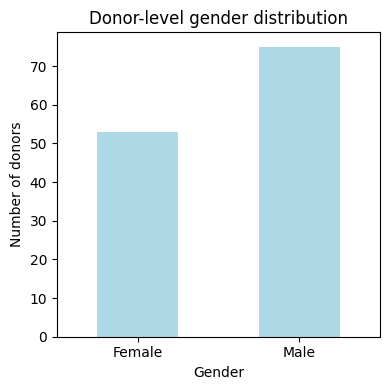

In [14]:
gender_meta_df = adata.obs[["pica_id", "Sex"]].drop_duplicates()

gender_meta_df["Sex"].value_counts().sort_index().plot(
    kind="bar", color="lightblue", figsize=(4,4)
)
plt.title("Donor-level gender distribution")
plt.xlabel("Gender")
plt.ylabel("Number of donors")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

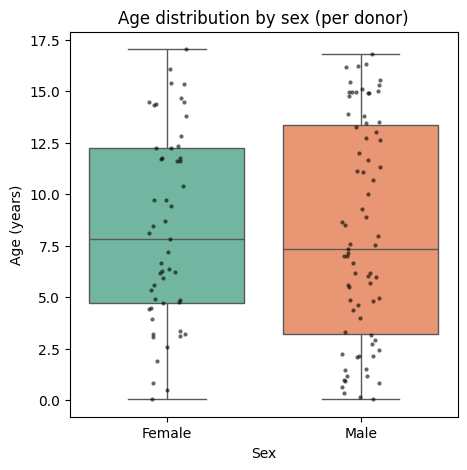

In [15]:
meta_df = adata.obs[['pica_id', "Sex", "Age_years"]].drop_duplicates()

plt.figure(figsize=(5,5))
sns.boxplot(data=meta_df, x="Sex", y="Age_years", palette="Set2")
sns.stripplot(data=meta_df, x="Sex", y="Age_years", color="k", size=3, alpha=0.6)
plt.title("Age distribution by sex (per donor)")
plt.ylabel("Age (years)")
plt.xlabel("Sex")
plt.show()

In [16]:
# clean types for downstream analysis
adata.obs = adata.obs.applymap(
    lambda x: str(x) if not isinstance(x, (int, float, str)) else x
)

In [17]:
adata.obs.groupby("pica_id")["Age_years"].unique()

pica_id
PICA0001     [2.09]
PICA0002    [15.09]
PICA0003     [0.83]
PICA0004     [1.46]
PICA0005      [9.3]
             ...   
PICA0164     [2.15]
PICA0166     [0.62]
PICA0168     [16.2]
PICA0169     [2.72]
PICA0173    [15.31]
Name: Age_years, Length: 128, dtype: object

In [18]:
adata.obs.groupby("pica_id")["Age"].unique()

pica_id
PICA0001     [2]
PICA0002    [15]
PICA0003     [0]
PICA0004     [1]
PICA0005     [9]
            ... 
PICA0164     [2]
PICA0166     [0]
PICA0168    [16]
PICA0169     [2]
PICA0173    [15]
Name: Age, Length: 128, dtype: object

In [20]:
# Define bins and labels
bins = [0, 3, 6, 10, 14, 18]
labels = ["0–3", "4–6", "7–10", "11–14", "15–18"]

# Create new column for grouped ages
adata.obs["Age_group"] = pd.cut(
    adata.obs["Age"],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=True
)

In [21]:
adata.obs["Age_group"].value_counts().sort_index()

Age_group
0–3      336749
4–6      352468
7–10     240674
11–14    416019
15–18    139231
Name: count, dtype: int64

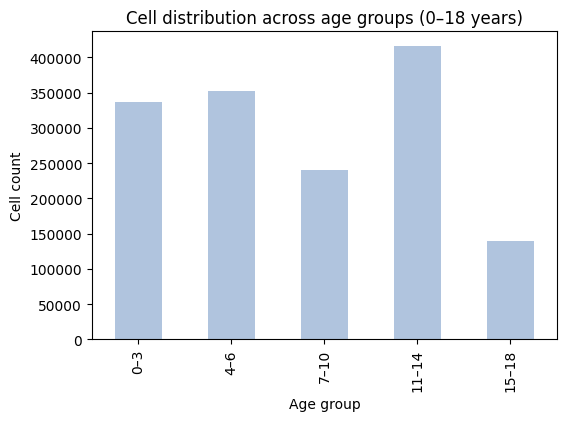

In [22]:
adata.obs["Age_group"].value_counts().sort_index().plot(
    kind="bar", figsize=(6,4), color="lightsteelblue"
)
plt.title("Cell distribution across age groups (0–18 years)")
plt.xlabel("Age group")
plt.ylabel("Cell count")
plt.show()

In [23]:
adata.obs.drop_duplicates(subset="pica_id").groupby(["Age_years", "Sex"]).size().reset_index(name="n_donors")

,Age_years,Sex,n_donors
0,0.05,Female,0
1,0.05,Male,1
2,0.07,Female,1
3,0.07,Male,0
4,0.14,Female,0
...,...,...,...
239,16.29,Male,1
240,16.78,Female,0
241,16.78,Male,1
242,17.03,Female,1


In [24]:
adata

AnnData object with n_obs × n_vars = 1485141 × 38606
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in

### Prepare sccoda

In [33]:
# build sccoda input from cell-level data
def make_sccoda_from_lineage(
    adata,
    cell_type_col="pica_cell_type_complete_01_gdT_corrected",   
    sample_col="pica_id",       
    covariates=("Age_years","Sex", "Batch","Age"), 
):
    sccoda_data = sccoda_model.load(
        adata,
        type="cell_level",
        generate_sample_level=True,
        cell_type_identifier=cell_type_col,
        sample_identifier=sample_col,
        covariate_obs=list(covariates),
    )
    return sccoda_data

In [34]:
sccoda_full = make_sccoda_from_lineage(adata, cell_type_col="pica_cell_type_complete_01_gdT_corrected")

In [35]:
sccoda_full

MuData object with n_obs × n_vars = 1485269 × 38643
  2 modalities
    rna:	1485141 x 38606
      obs:	'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)", "9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? (choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please specify:)", 'Specify ethnicity', 'Batch', 'Age_group', 'scCODA_sample_id'
      var:	'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb'
    coda:	128 x 37
      obs:	'Batch', 'Age', 'Age_years', 'pica_id', 'Sex'
      var:	'n_cells'

In [36]:
coda = sccoda_full["coda"].copy()

In [37]:
coda.obs["Batch"] = coda.obs["Batch"].astype("category")
coda.obs["Age_years"] = coda.obs["Age_years"].astype("float")
coda.obs["Sex"] = coda.obs["Sex"].astype("category")
coda.obs["Age"] = coda.obs["Age"].astype("int")

In [38]:
coda

AnnData object with n_obs × n_vars = 128 × 37
    obs: 'Batch', 'Age', 'Age_years', 'pica_id', 'Sex'
    var: 'n_cells'

In [39]:
del sccoda_full

## Run sccoda

In [40]:
# prepare sccoda model
def prepare_sccoda_age(sccoda_data, modality_key="coda", ref="automatic"):
    formula = "~ Age_years * Sex + Batch"

    sccoda_data = sccoda_model.prepare(
        sccoda_data,
        modality_key=modality_key,
        formula=formula,
        reference_cell_type=ref,  # or e.g. "CD4_naive"
    )
    return sccoda_data

In [41]:
# run sccoda
def run_sccoda(sccoda_data, modality_key="coda", rng_key=0):
    sccoda_model.run_nuts(
        sccoda_data,
        modality_key=modality_key,
        num_warmup=2000,
        num_samples=5000,
        rng_key=rng_key,
    )
    return sccoda_data


#### automatic ref cell type model

In [42]:
full_cell = prepare_sccoda_age(coda.copy(), ref="automatic")

• Automatic reference selection! Reference cell type set to nILC2
• Zero counts encountered in data! Added a pseudocount of 0.5.


In [43]:
full_cell = run_sccoda(full_cell, rng_key=1)

sample: 100%|██████████| 7000/7000 [20:20<00:00,  5.74it/s, 511 steps of size 8.10e-03. acc. prob=0.83] 


In [44]:
sccoda_model.summary(full_cell, modality_key="coda", extended=True)

                                          Compositional Analysis summary                                           
┌───────────────────────────────────────┬─────────────────────────────────────────────────────────────────────────┐
│ Name                                  │ Value                                                                   │
├───────────────────────────────────────┼─────────────────────────────────────────────────────────────────────────┤
│ Data                                  │ Data: 128 samples, 37 cell types                                        │
│ Reference cell type                   │ nILC2                                                                   │
│ Formula                               │ ~ Age_years * Sex + Batch                                               │
│ Reference index                       │ 35                                                                      │
│ Spike-and-slab threshold              │ 0.814                                                                   │
│ Spike-and-slab threshold              │ 0.814                                                                   │
│ MCMC Sampling                         │ Sampled 5000 chain states (2000 burnin samples)                         │
│ Acceptance rate                       │ 82.9%                                                                   │
└───────────────────────────────────────┴─────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Intercepts                                                                                                      │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                           Final Parameter  HDI 3%  HDI 97%   SD   Expected Sample               │
│ pica_cell_type_complete_01_gdT_corrected                                                                        │
│ Atypical memory B cell                        -0.198       -0.501   0.085  0.154       88.590                   │
│ CD4 Tem                                        1.079        0.860   1.302  0.119      317.672                   │
│ CD4 cytoT                                     -0.569       -0.895  -0.244  0.179       61.131                   │
│ CD4 naive/Tcm                                  3.573        3.431   3.720  0.076     3846.881                   │
│ CD8 GZMK+ naive/Tcm                            0.816        0.593   1.069  0.127      244.207                   │
│ CD8 Tem                                        0.783        0.606   0.963  0.096      236.280                   │
│ CD8 naive/Tcm                                  2.449        2.287   2.592  0.081     1250.149                   │
│ CD56_bright CD16- NK                          -1.422       -1.781  -1.041  0.196       26.050                   │
│ CD56_dim CD16+ KLRC2+ NK                      -0.051       -0.397   0.332  0.200      102.618                   │
│ CD56_dim CD16+ NK                              2.573        2.343   2.804  0.122     1415.188                   │
│ CR2- B cell                                   -1.706       -1.947  -1.434  0.136       19.610                   │
│ CX3CR1_high ncMonocyte                         0.342        0.105   0.569  0.123      152.021                   │
│ CX3CR1_low ncMonocyte                         -1.526       -1.767  -1.240  0.140       23.477                   │
│ Classical monocyte                             0.570        0.269   0.854  0.157      190.951                   │
│ DN T                                          -0.775       -1.107  -0.428  0.185       49.750                   │
│ DP T                                          -0.637       -0.933  -0.307  0.165       57.112                   │
│ GNLY+ B                                       -1.487       -1.773  -1.226  0.143       24.411                   │
│ HSPC                                          -1.421       -1.754  -1.112  0.168       26.076                   │
│ ILC1                                           0.425        0.200   0.637  0.115      165.177                   │
│ Intermediate monocyte                         -0.370       -0.746   0.004  0.200       74.591                   │
│ MAIT                                          -0.181       -0.466   0.109  0.153       90.109                   │
│ NKT                                           -1.668       -1.965  -1.400  0.148       20.369                   │
│ Naive B cell                                   1.729        1.484   1.980  0.132      608.513                   │
│ Non-switched memory B cell                    -1.688       -1.958  -1.421  0.142       19.966                   │
│ Plasma cell                                   -0.806       -1.065  -0.579  0.127       48.232                   │
│ Platelet                                      -0.752       -1.050  -0.438  0.164       50.908                   │
│ Proliferating lymphocyte                      -0.885       -1.192  -0.591  0.161       44.568                   │
│ Switched memory B cell                         1.178        1.019   1.368  0.091      350.730                   │
│ Tfh                                            0.911        0.687   1.146  0.124      268.545                   │
│ Transitional B cell                            0.889  

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects                                                                                                         │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                                 Final Parameter  Expected Sample  log2-fold change              │
│ Covariate           Cell Type                                                                                   │
│ SexT.Male           Atypical memory B cell           0.000            86.636           -0.032                   │
│                     CD4 Tem                          0.000           310.666           -0.032                   │
│                     CD4 cytoT                        0.000            59.783           -0.032                   │
│                     CD4 naive/Tcm                    0.000          3762.043           -0.032                   │
│                     CD8 GZMK+ naive/Tcm              0.000           238.822           -0.032                   │
│                     CD8 Tem                          0.000           231.069           -0.032                   │
│                     CD8 naive/Tcm                    0.000          1222.579           -0.032                   │
│                     CD56_bright CD16- NK             0.000            25.476           -0.032                   │
│                     CD56_dim CD16+ KLRC2+ NK         0.000           100.355           -0.032                   │
│                     CD56_dim CD16+ NK                0.170          1639.925            0.213                   │
│                     CR2- B cell                      0.000            19.177           -0.032                   │
│                     CX3CR1_high ncMonocyte           0.000           148.668           -0.032                   │
│                     CX3CR1_low ncMonocyte            0.000            22.959           -0.032                   │
│                     Classical monocyte               0.000           186.740           -0.032                   │
│                     DN T                             0.000            48.653           -0.032                   │
│                     DP T                             0.000            55.853           -0.032                   │
│                     GNLY+ B                          0.000            23.872           -0.032                   │
│                     HSPC                             0.000            25.501           -0.032                   │
│                     ILC1                             0.000           161.534           -0.032                   │
│                     Intermediate monocyte            0.000            72.946           -0.032                   │
│                     MAIT                             0.000            88.122           -0.032                   │
│                     NKT                              0.000            19.920           -0.032                   │
│                     Naive B cell                     0.000           595.093           -0.032                   │
│                     Non-switched memory B cell       0.000            19.525           -0.032                   │
│                     Plasma cell                      0.000            47.168           -0.032                   │
│                     Platelet                         0.000            49.785           -0.032                   │
│                     Proliferating lymphocyte         0.000            43.585           -0.032                   │
│                     Switched memory B cell           0.000           342.996           -0.032                   │
│                     Tfh                              0.000           262.622           -0.032                   │
│                     Transitional B cell              0

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects Extended                                                                                                │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                                 HDI 3%  HDI 97%   SD   Inclusion probability                    │
│ Covariate           Cell Type                                                                                   │
│ SexT.Male           Atypical memory B cell      -0.234   0.139  0.074         0.486                             │
│                     CD4 Tem                     -0.271   0.024  0.087         0.704                             │
│                     CD4 cytoT                   -0.236   0.151  0.075         0.501                             │
│                     CD4 naive/Tcm               -0.181   0.025  0.058         0.623                             │
│                     CD8 GZMK+ naive/Tcm         -0.208   0.114  0.062         0.467                             │
│                     CD8 Tem                     -0.152   0.204  0.065         0.472                             │
│                     CD8 naive/Tcm               -0.076   0.157  0.045         0.402                             │
│                     CD56_bright CD16- NK        -0.192   0.190  0.071         0.478                             │
│                     CD56_dim CD16+ KLRC2+ NK    -0.144   0.210  0.067         0.491                             │
│                     CD56_dim CD16+ NK           -0.000   0.290  0.084         0.924                             │
│                     CR2- B cell                 -0.185   0.198  0.072         0.484                             │
│                     CX3CR1_high ncMonocyte      -0.207   0.141  0.063         0.461                             │
│                     CX3CR1_low ncMonocyte       -0.205   0.188  0.072         0.486                             │
│                     Classical monocyte          -0.266   0.133  0.084         0.528                             │
│                     DN T                        -0.234   0.180  0.076         0.504                             │
│                     DP T                        -0.170   0.198  0.068         0.491                             │
│                     GNLY+ B                     -0.166   0.224  0.075         0.510                             │
│                     HSPC                        -0.202   0.200  0.075         0.500                             │
│                     ILC1                        -0.128   0.205  0.063         0.467                             │
│                     Intermediate monocyte       -0.182   0.194  0.068         0.476                             │
│                     MAIT                        -0.359   0.036  0.116         0.765                             │
│                     NKT                         -0.192   0.201  0.071         0.475                             │
│                     Naive B cell                -0.034   0.253  0.079         0.654                             │
│                     Non-switched memory B cell  -0.170   0.226  0.077         0.498                             │
│                     Plasma cell                 -0.231   0.158  0.074         0.485                             │
│                     Platelet                    -0.178   0.199  0.073         0.503                             │
│                     Proliferating lymphocyte    -0.240   0.162  0.078         0.503                             │
│                     Switched memory B cell      -0.142   0.156  0.052         0.439                             │
│                     Tfh                         -0.284   0.053  0.094         0.655                             │
│                     Transitional B cell         -0.110

In [45]:
# set desired FDR globally
sccoda_model.set_fdr(full_cell, est_fdr=0.2, modality_key="coda")


In [47]:
full_cell

AnnData object with n_obs × n_vars = 128 × 37
    obs: 'Batch', 'Age', 'Age_years', 'pica_id', 'Sex'
    var: 'n_cells'
    uns: 'scCODA_params'
    obsm: 'covariate_matrix', 'sample_counts'
    varm: 'intercept_df', 'effect_df_Sex[T.Male]', 'effect_df_Batch[T.Batch02]', 'effect_df_Batch[T.Batch03]', 'effect_df_Batch[T.Batch04]', 'effect_df_Batch[T.Batch05]', 'effect_df_Batch[T.Batch06]', 'effect_df_Batch[T.Batch07]', 'effect_df_Age_years', 'effect_df_Age_years:Sex[T.Male]'

In [48]:
# check threshold
full_cell.uns["scCODA_params"]["threshold_prob"]

np.float64(0.549)

In [49]:
effects_full = sccoda_model.get_effect_df(full_cell, modality_key="coda")

effects_full["Inclusion probability"].max()
effects_full["Inclusion probability"].describe()


count    333.000000
mean       0.500705
std        0.216485
min        0.000000
25%        0.392200
50%        0.459800
75%        0.550600
max        1.000000
Name: Inclusion probability, dtype: float64

In [50]:

# effects dataframe
effects_full = sccoda_model.get_effect_df(full_cell, modality_key="coda")
effects_full.head()

Final Parameter  HDI 3%  HDI 97%     SD  \
Covariate Cell Type                                                         
SexT.Male Atypical memory B cell         0.000000  -0.234    0.139  0.074   
          CD4 Tem                       -0.117457  -0.271    0.024  0.087   
          CD4 cytoT                      0.000000  -0.236    0.151  0.075   
          CD4 naive/Tcm                 -0.075208  -0.181    0.025  0.058   
          CD8 GZMK+ naive/Tcm            0.000000  -0.208    0.114  0.062   

                                  Inclusion probability  Expected Sample  \
Covariate Cell Type                                                        
SexT.Male Atypical memory B cell                 0.4860        89.829853   
          CD4 Tem                                0.7038       286.420381   
          CD4 cytoT                              0.5014        61.986546   
          CD4 naive/Tcm                          0.6230      3618.117031   
          CD8 GZMK+ naive/Tcm                    0.4670       247.625460   

                                  log2-fold change  
Covariate Cell Type                                 
SexT.Male Atypical memory B cell          0.020053  
          CD4 Tem                        -0.149402  
          CD4 cytoT                       0.020053  
          CD4 naive/Tcm                  -0.088450  
          CD8 GZMK+ naive/Tcm             0.020053

In [53]:
# counts per sample x celltype
counts = pd.DataFrame(
    full_cell.X,
    index=full_cell.obs_names,
    columns=full_cell.var_names,
)

# convert to proportions
props = counts.div(counts.sum(axis=1), axis=0)

# metadata (sample-level)
meta = full_cell.obs.copy()

# long format for plotting
df = (
    props.join(meta[["Age_years", "Age"]])
    .reset_index(names="sample")
    .melt(
        id_vars=["sample", "Age_years", "Age"],
        var_name="pica_cell_type_complete_01_gdT_corrected",
        value_name="Proportion",
    )
)

In [54]:
df["pica_cell_type_complete_01_gdT_corrected"].unique()

array(['Atypical memory B cell', 'CD4 Tem', 'CD4 cytoT', 'CD4 naive/Tcm',
       'CD8 GZMK+ naive/Tcm', 'CD8 Tem', 'CD8 naive/Tcm',
       'CD56_bright CD16- NK', 'CD56_dim CD16+ KLRC2+ NK',
       'CD56_dim CD16+ NK', 'CR2- B cell', 'CX3CR1_high ncMonocyte',
       'CX3CR1_low ncMonocyte', 'Classical monocyte', 'DN T', 'DP T',
       'GNLY+ B', 'HSPC', 'ILC1', 'Intermediate monocyte', 'MAIT', 'NKT',
       'Naive B cell', 'Non-switched memory B cell', 'Plasma cell',
       'Platelet', 'Proliferating lymphocyte', 'Switched memory B cell',
       'Tfh', 'Transitional B cell', 'Treg', 'cDC1', 'cDC2', 'gdT',
       'iILC2', 'nILC2', 'pDC'], dtype=object)

In [55]:
df["Age"].unique()

array([ 2, 15,  0,  1,  9,  3,  4,  5, 13,  6,  7, 10, 16, 12, 11, 14,  8,
       17])

In [69]:
lineage_map = {
    "CD4 Tem": "CD4 T cells",
    "CD4 cytoT": "CD4 T cells",
    "CD4 naive/Tcm": "CD4 T cells",
    "Tfh": "CD4 T cells",
    "Treg": "CD4 T cells",
    "CD8 Tem": "CD8 T cells",
    "CD8 naive/Tcm": "CD8 T cells",
    "CD8 GZMK+ naive/Tcm": "CD8 T cells",
    "DN T": "T cells",
    "DP T": "T cells",
    "gdT": "T cells",

    "CD56 bright CD16- NK": "NK",
    "CD56_dim CD16+ NK": "NK",
    "CD56_dim CD16+ KLRC2+ NK": "NK",
    "ILC1": "ILC",
    "ILC2": "ILC",
    "nILC2": "ILC",

    "Naive B cell": "B cells",
    "Non-switched memory B cell": "B cells",
    "Switched memory B cell": "B cells",
    "Atypical memory B cell": "B cells",
    "Transitional B cell": "B cells",
    "Plasma cell": "B cells",

    "Classical monocyte": "Myeloid",
    "Intermediate monocyte": "Myeloid",
    "CX3CR1_high ncMonocyte": "Myeloid",
    "CX3CR1_low ncMonocyte": "Myeloid",
    "cDC1": "Myeloid",
    "cDC2": "Myeloid",
    "pDC": "Myeloid",

    "MAIT": "Other",
    "NKT": "Other",
    "Platelet": "Other",
    "HSPC": "Other",
    "Proliferating lymphocyte": "Other",
    "CR2- B cell": "Other",
    "GNLY+ B": "Other"

}

In [70]:
df["lineage"] = df["pica_cell_type_complete_01_gdT_corrected"].map(lineage_map)

# fill anything unmapped
df["lineage"] = df["lineage"].fillna("Other")

# desired lineage order
lineage_order = [
    "CD4 T cells",
    "CD8 T cells",
    "T cells",
    "NK",
    "ILC",
    "B cells",
    "Myeloid",
    "Other"
]

# desired cell-type order within each lineage
cell_type_order = [
    "CD4 naive/Tcm", "CD4 Tem", "CD4 cytoT", "Tfh", "Treg",
    "CD8 naive/Tcm", "CD8 GZMK+ naive/Tcm", "CD8 Tem",
    "DN T", "DP T", "gdT",
    "CD56 bright CD16- NK", "CD56_dim CD16+ NK", "CD56_dim CD16+ KLRC2+ NK",
    "ILC1", "ILC2", "nILC2",
    "Naive B cell", "Transitional B cell", "Atypical memory B cell",
    "Non-switched memory B cell", "Switched memory B cell", "Plasma cell",
    "Classical monocyte", "Intermediate monocyte",
    "CX3CR1_high ncMonocyte", "CX3CR1_low ncMonocyte",
    "cDC1", "cDC2", "pDC",
    "MAIT", "NKT", "GNLY+ B", "HSPC", "Platelet", "Proliferating lymphocyte", "CR2- B cell"
]

# apply categorical ordering
df["lineage"] = pd.Categorical(df["lineage"], categories=lineage_order, ordered=True)
df["pica_cell_type_complete_01_gdT_corrected"] = pd.Categorical(
    df["pica_cell_type_complete_01_gdT_corrected"],
    categories=cell_type_order,
    ordered=True
)

# sort once
df = df.sort_values(["lineage", "pica_cell_type_complete_01_gdT_corrected"])

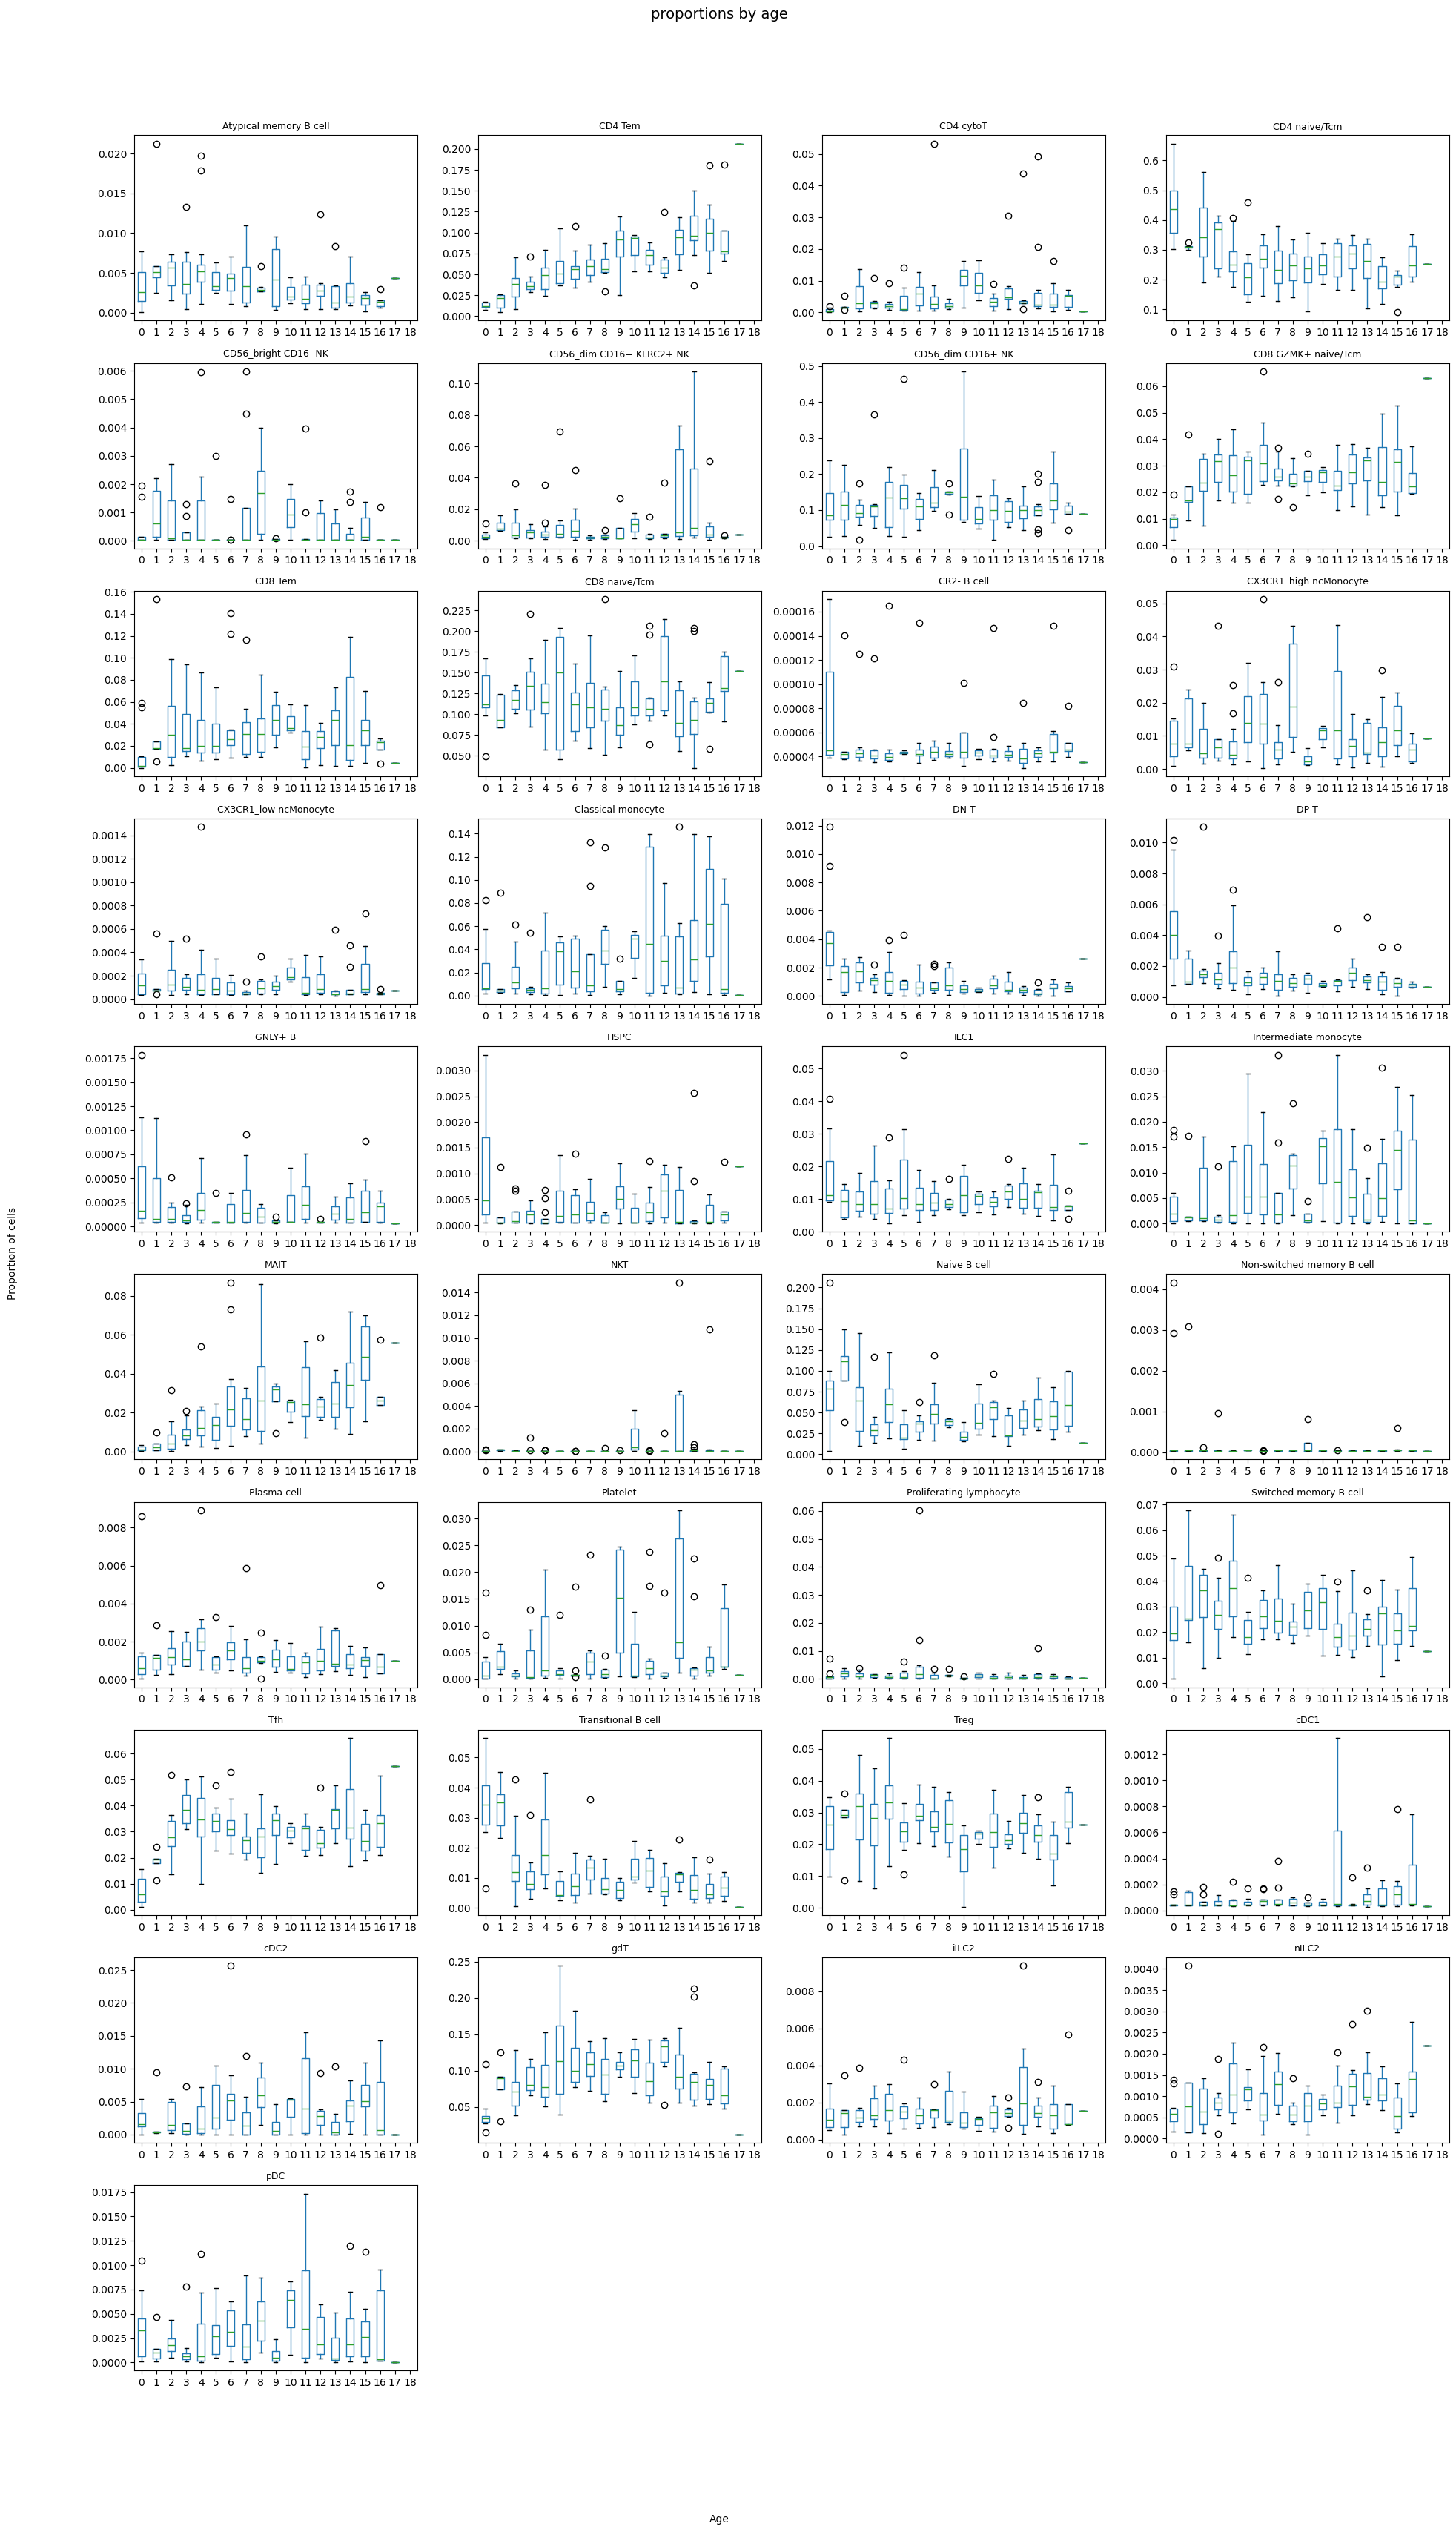

In [ ]:
# boxplots of relative abundances per donor per age group
cell_types = sorted(df["pica_cell_type_complete_01_gdT_corrected"].unique())

n_cols = 4
n_rows = math.ceil(len(cell_types) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
axes = axes.flatten()

for ax, cell in zip(axes, cell_types):
    sub = df[df["pica_cell_type_complete_01_gdT_corrected"] == cell]
    sub.boxplot(column="Proportion", by="Age", grid=False, ax=ax)

    ax.set_xticks(range(1, 20))
    ax.set_xticklabels(range(0, 19))
    ax.set_xlim(0.5, 19.5)

    ax.set_title(cell, fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in axes[len(cell_types):]:
    ax.axis("off")

plt.suptitle("proportions by age", fontsize=14)
fig.supxlabel("Age", fontsize=10)
fig.supylabel("Proportion of cells", fontsize=10)

plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])
plt.show()

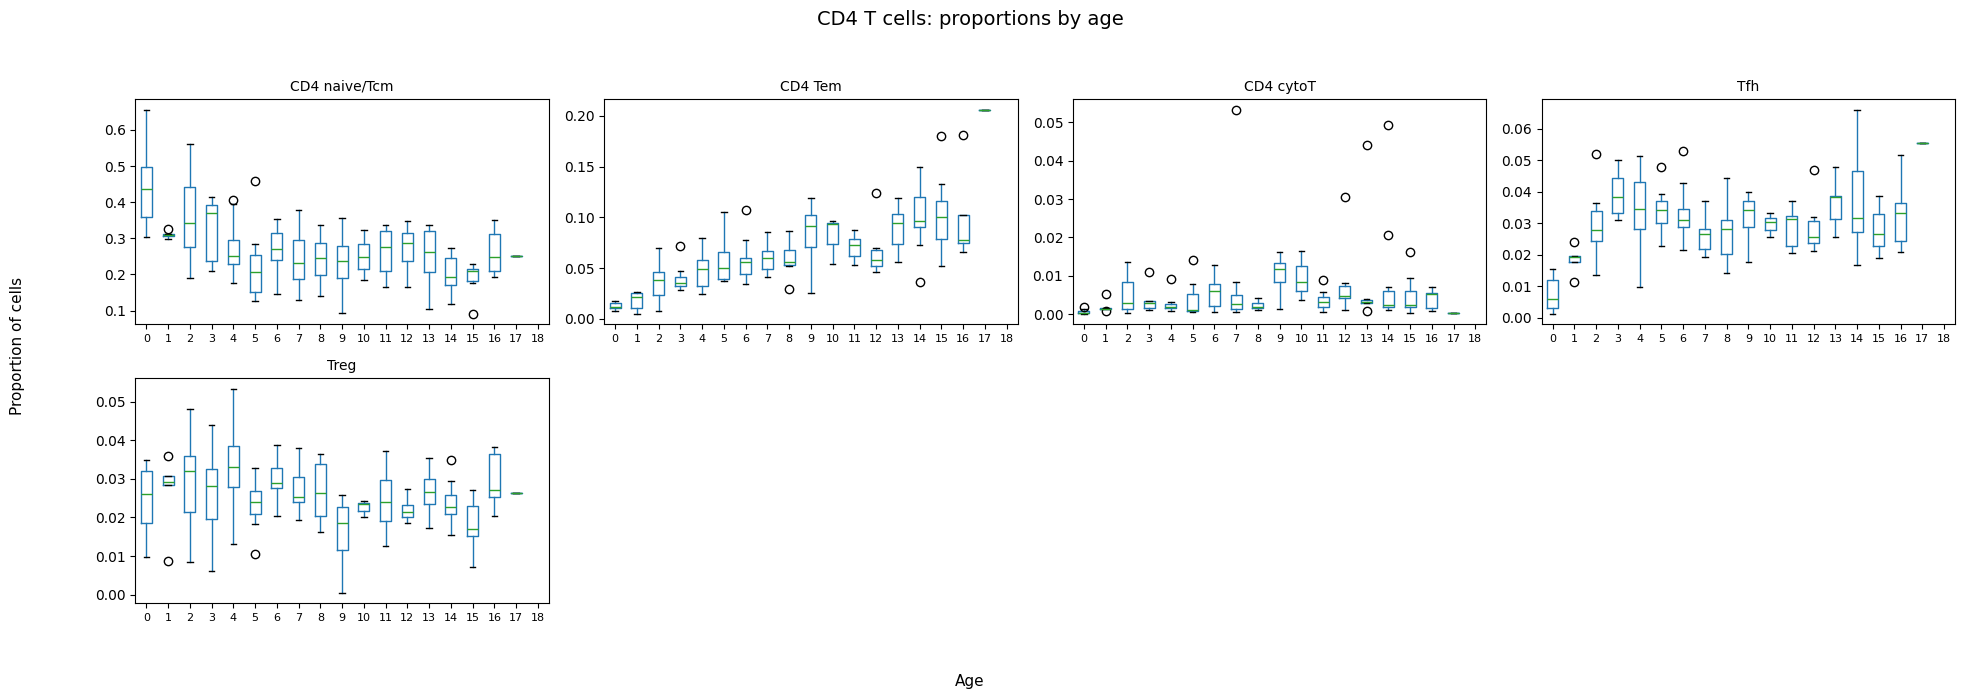

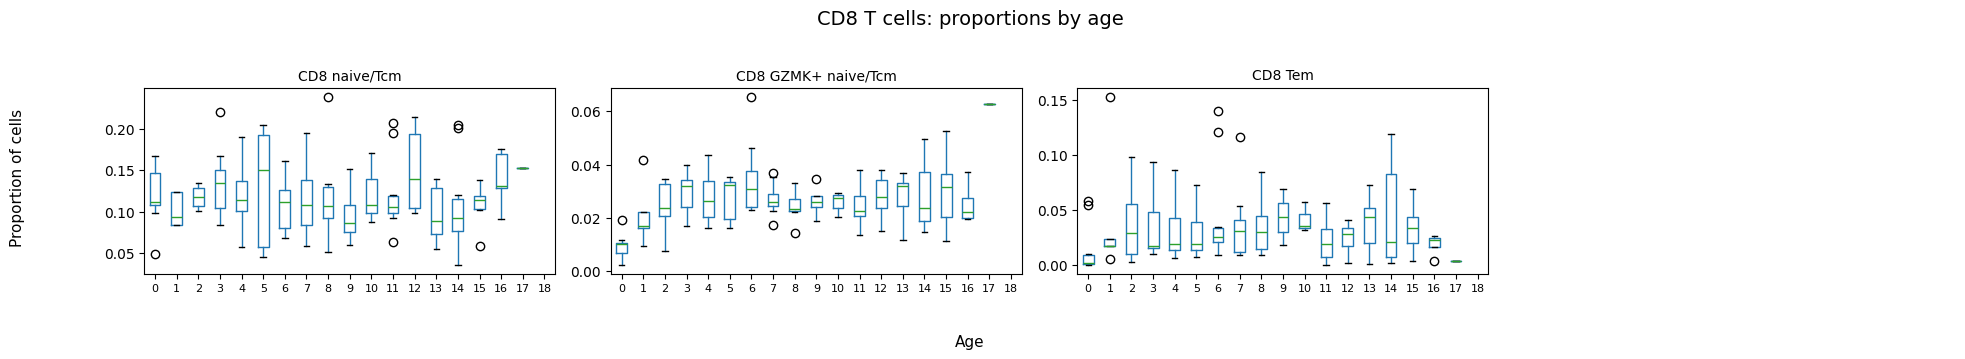

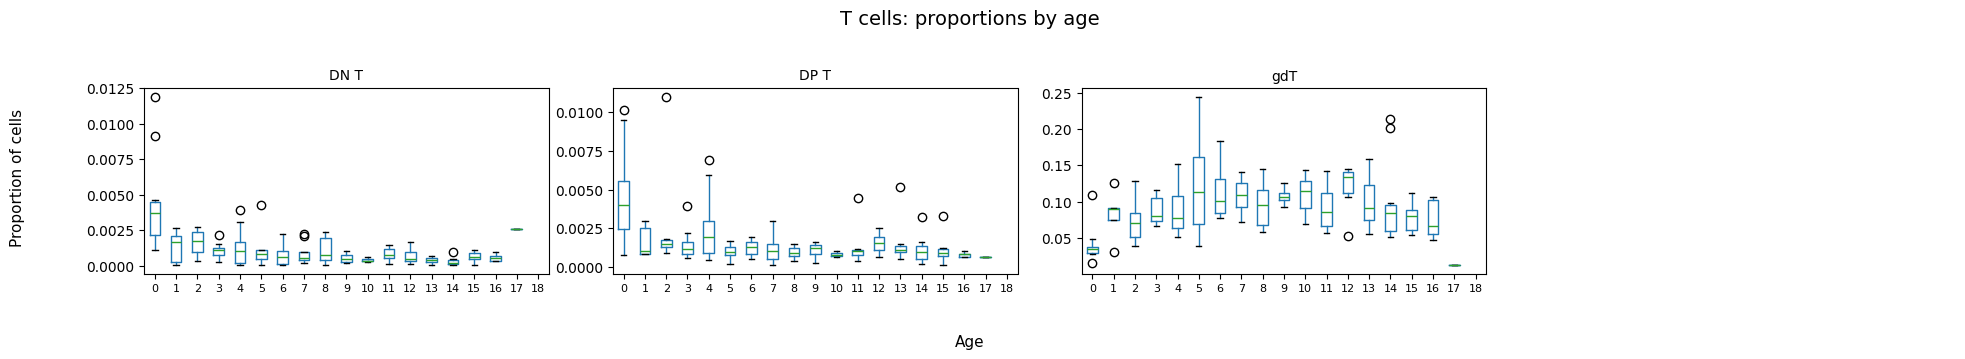

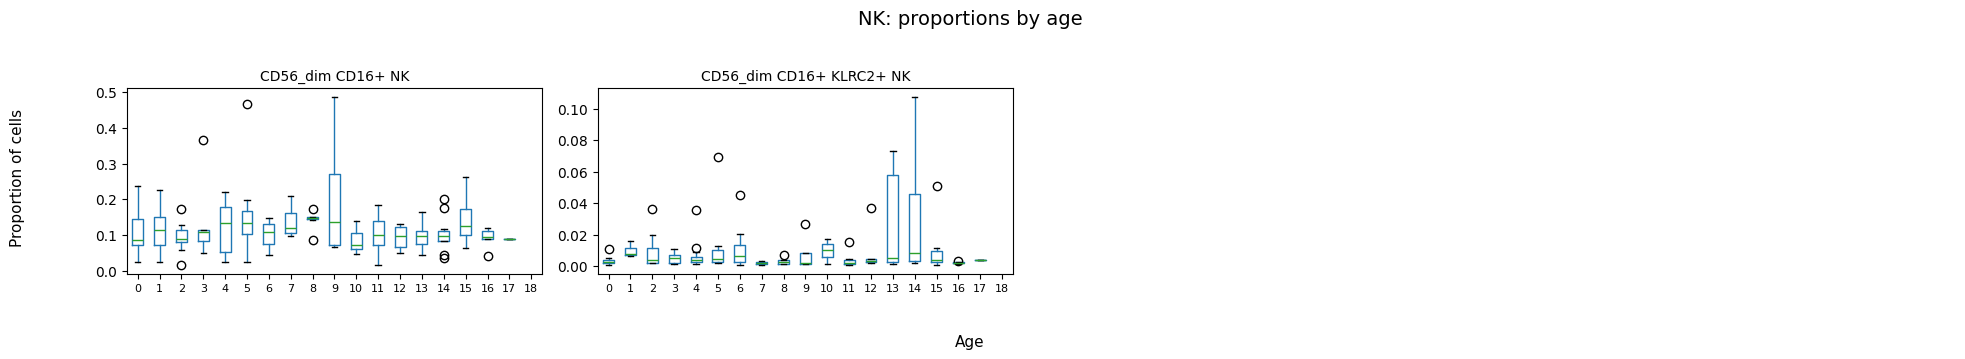

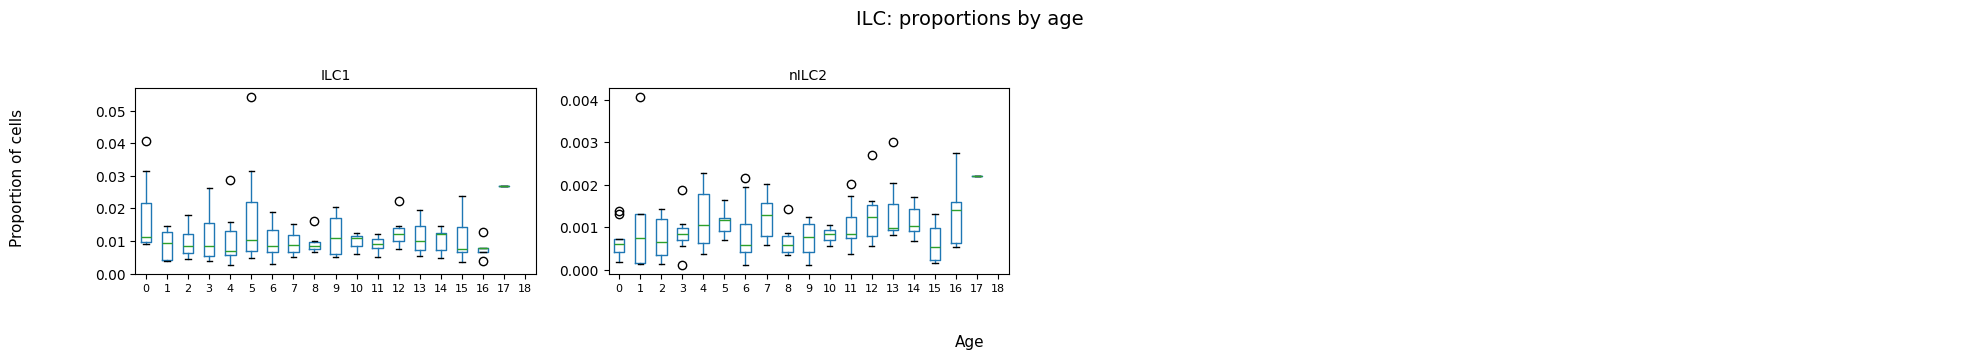

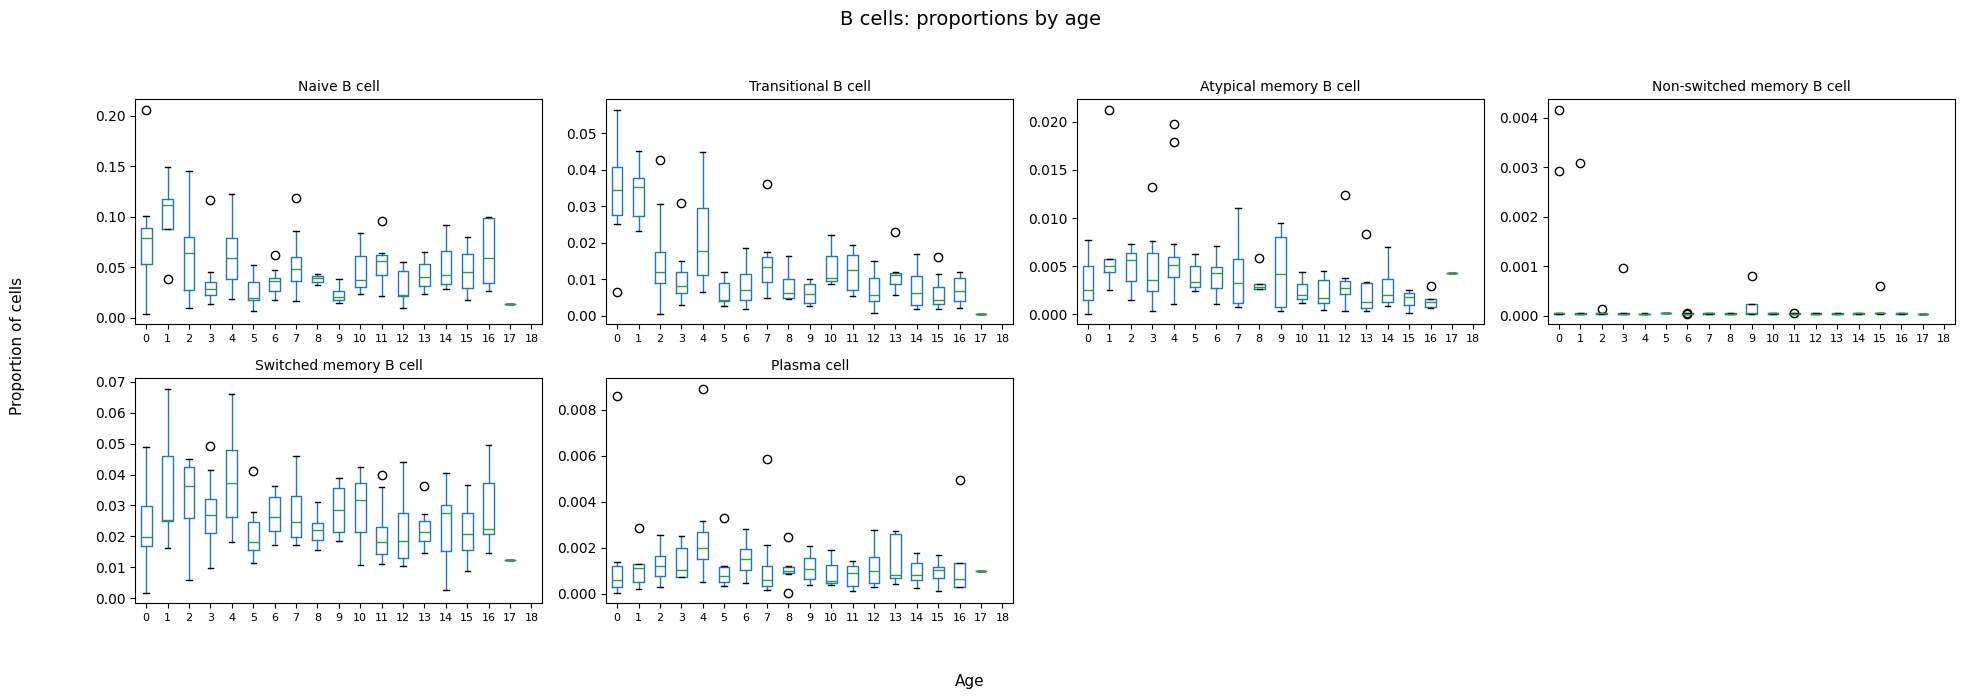

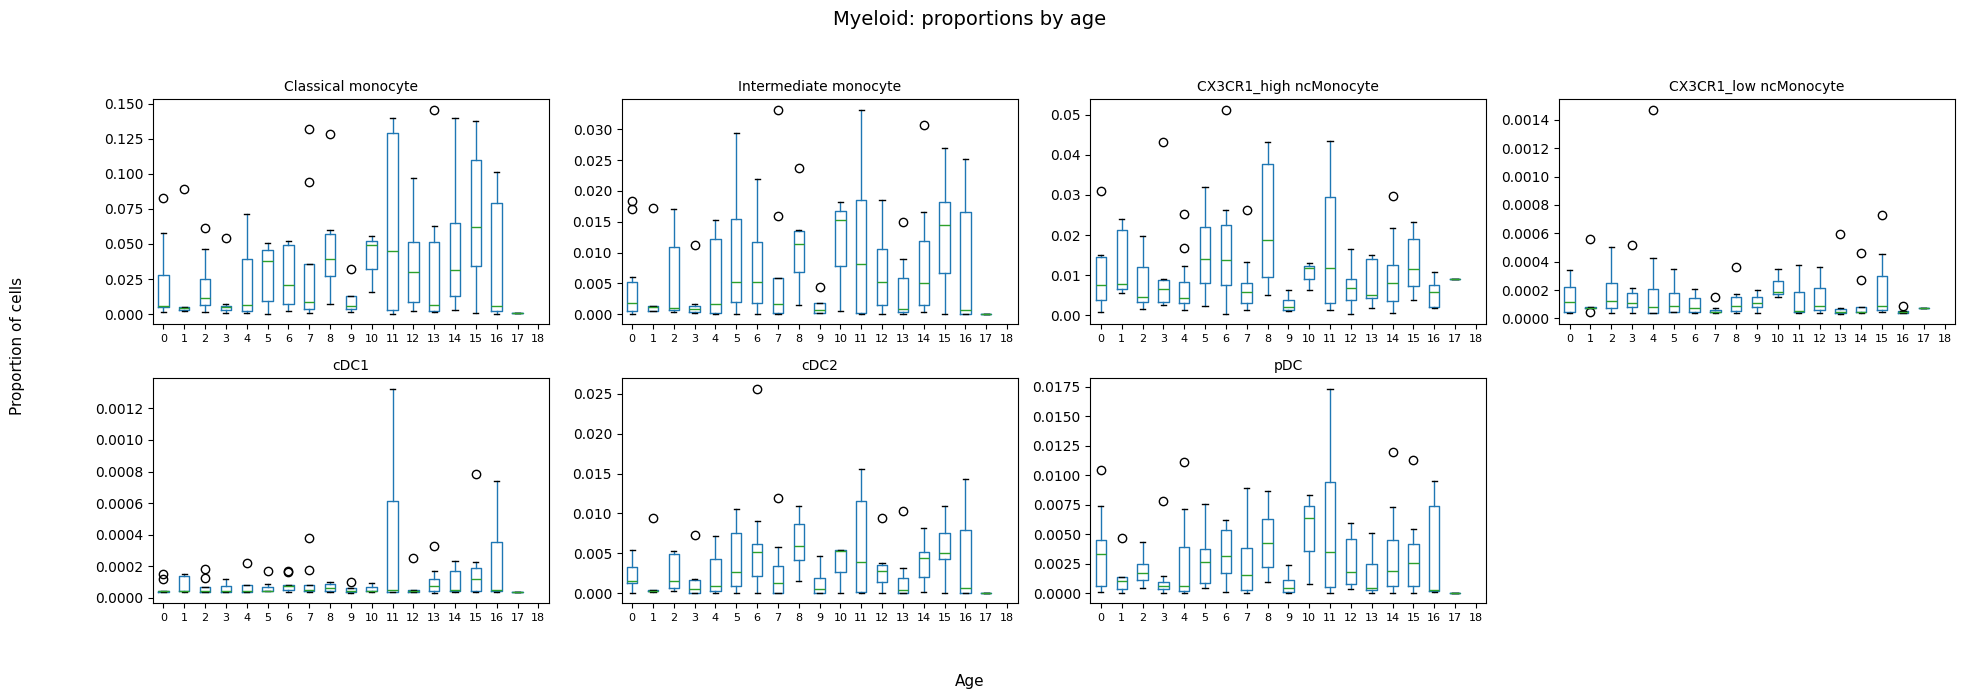

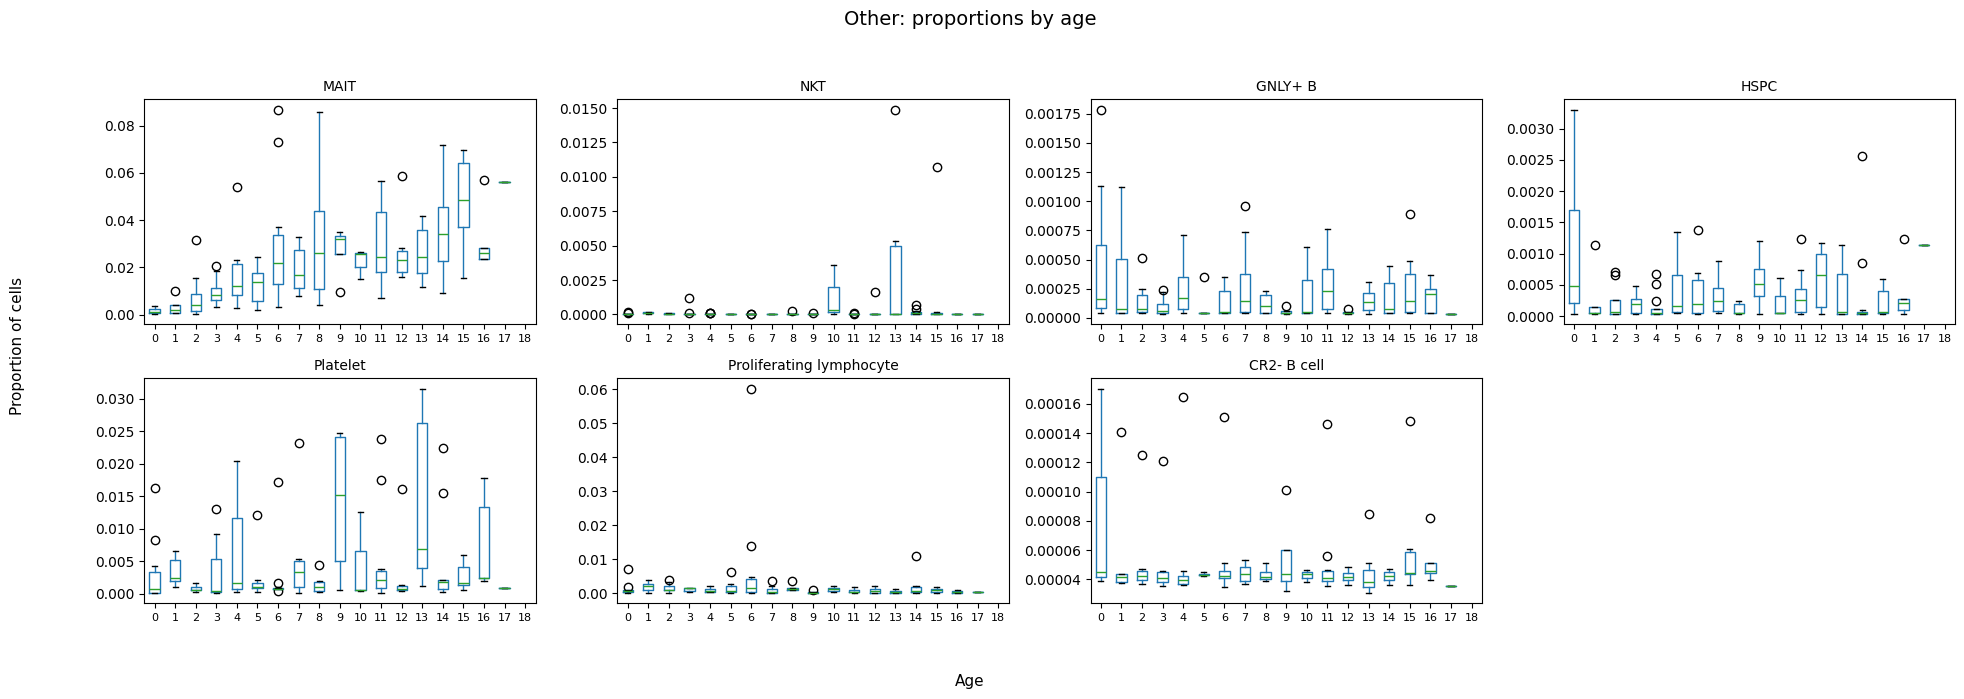

In [71]:
for lineage in lineage_order:
    sub_df = df[df["lineage"] == lineage].copy()
    
    if sub_df.empty:
        continue
    
    cell_types = [x for x in cell_type_order if x in sub_df["pica_cell_type_complete_01_gdT_corrected"].astype(str).unique()]
    
    n_cols = 4
    n_rows = math.ceil(len(cell_types) / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
    axes = np.array(axes).flatten()

    for ax, cell in zip(axes, cell_types):
        tmp = sub_df[sub_df["pica_cell_type_complete_01_gdT_corrected"].astype(str) == cell]
        tmp.boxplot(column="Proportion", by="Age", grid=False, ax=ax)

        ax.set_xticks(range(1, 20))
        ax.set_xticklabels(range(0, 19), fontsize=8)
        ax.set_xlim(0.5, 19.5)
        ax.set_title(cell, fontsize=10)
        ax.set_xlabel("")
        ax.set_ylabel("")

    for ax in axes[len(cell_types):]:
        ax.axis("off")

    plt.suptitle("")
    fig.suptitle(f"{lineage}: proportions by age", fontsize=14)
    fig.supxlabel("Age", fontsize=11)
    fig.supylabel("Proportion of cells", fontsize=11)
    plt.tight_layout(rect=[0.04, 0.04, 1, 0.95])
    plt.show()

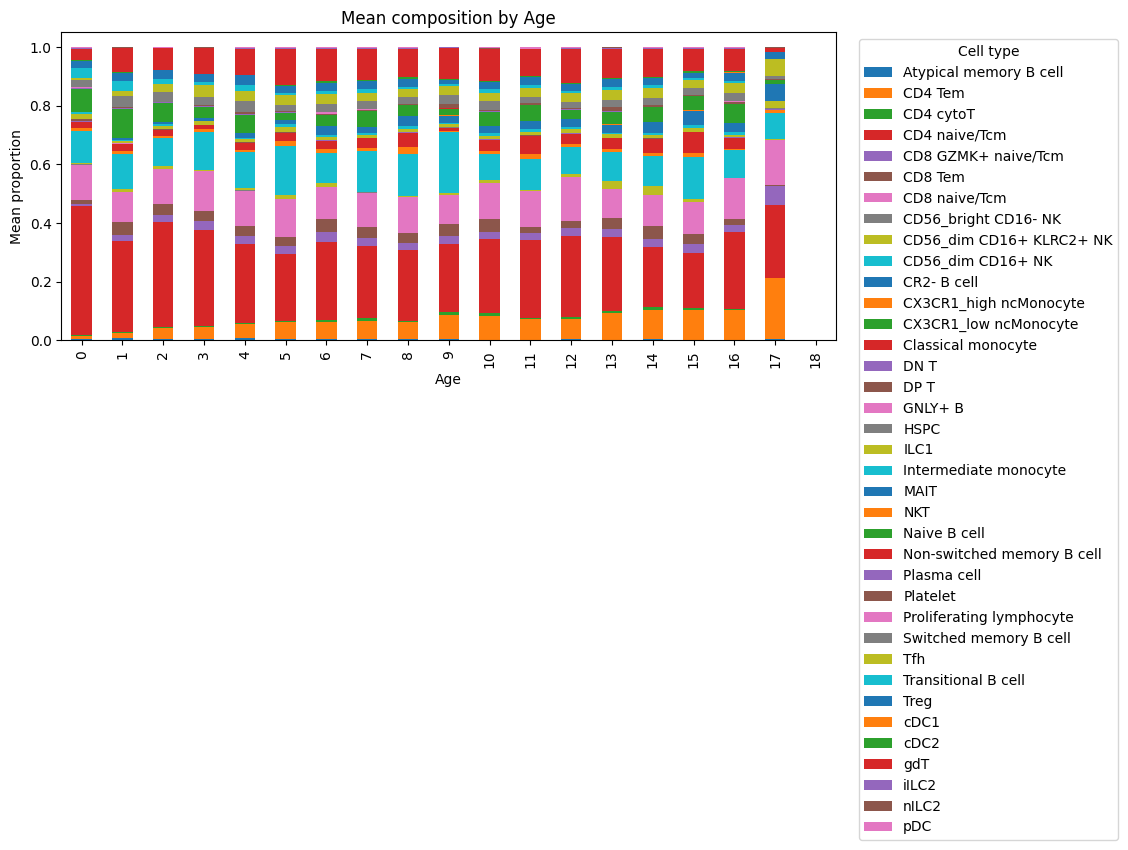

In [57]:
# barplot of composition by age group
props_age = (props.join(meta["Age"]).groupby("Age").mean().reindex(range(0, 19)))

ax = props_age.plot(kind="bar", stacked=True, figsize=(10, 4))
ax.set_xlabel("Age")
ax.set_ylabel("Mean proportion")
ax.set_title("Mean composition by Age")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Cell type")
plt.tight_layout()
plt.show()

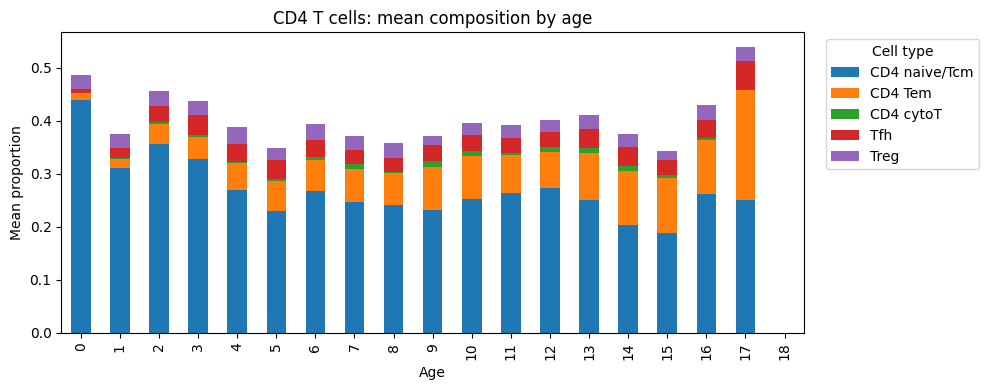

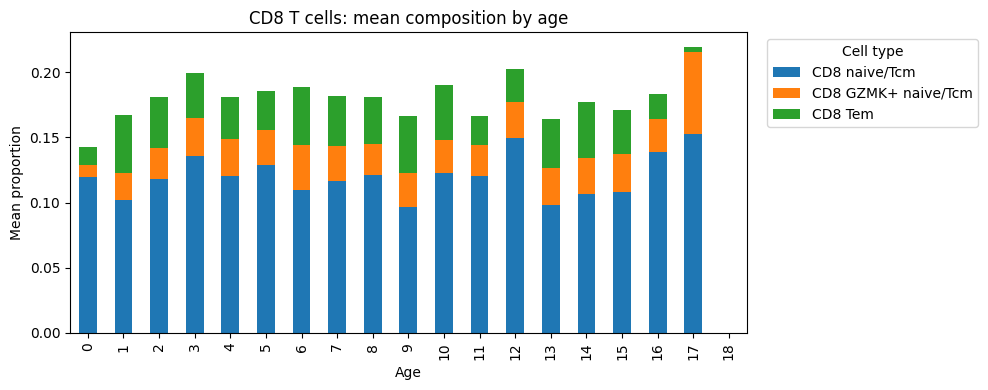

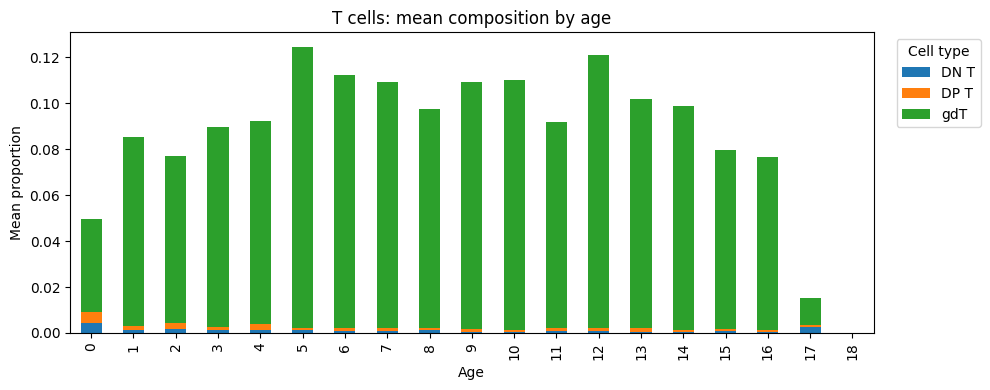

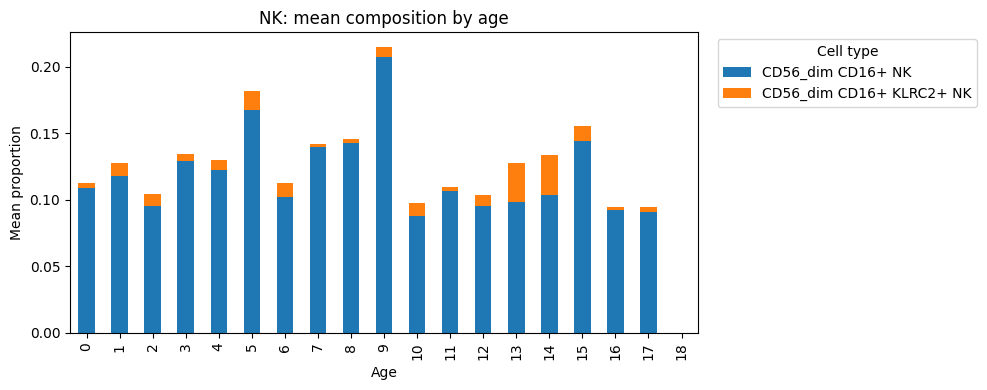

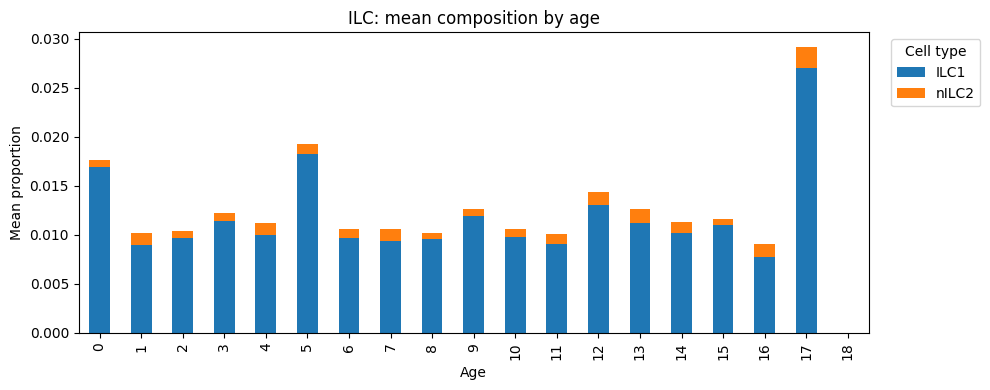

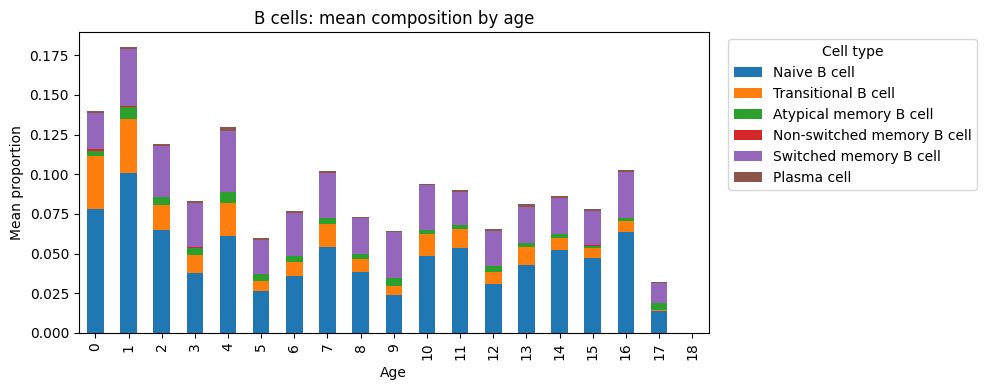

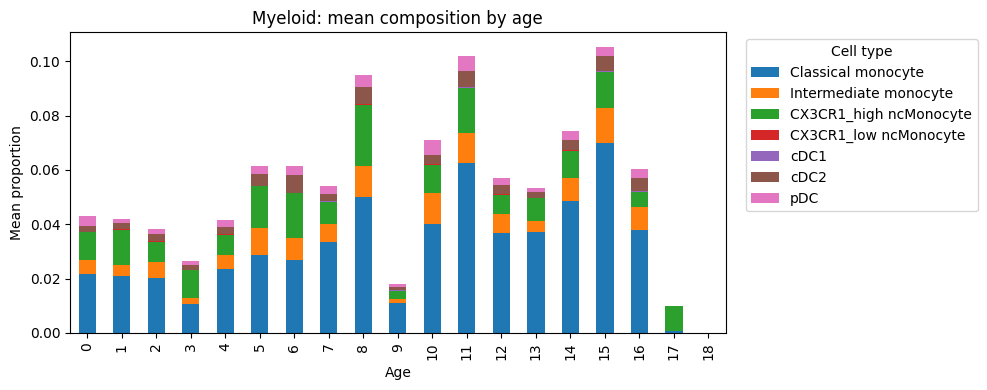

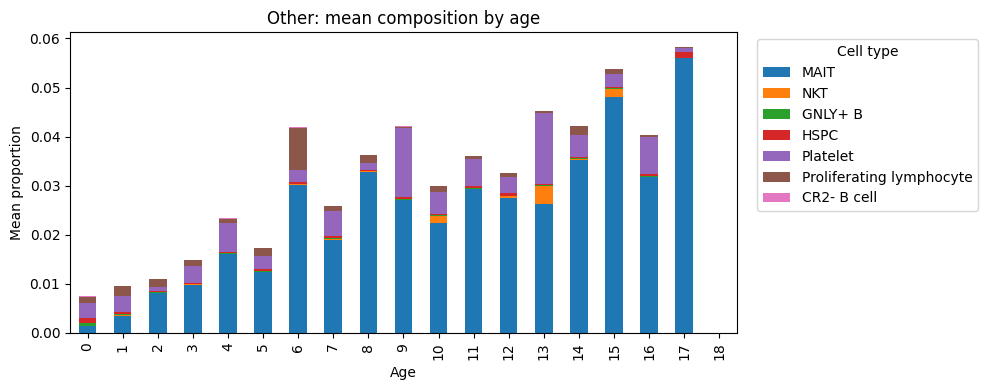

In [72]:
props_age = props.join(meta["Age"]).groupby("Age").mean().reindex(range(0, 19))

for lineage in lineage_order:
    lineage_cells = [ct for ct, grp in lineage_map.items() if grp == lineage]
    lineage_cells = [ct for ct in cell_type_order if ct in lineage_cells and ct in props_age.columns]
    
    if len(lineage_cells) == 0:
        continue
    
    ax = props_age[lineage_cells].plot(
        kind="bar",
        stacked=True,
        figsize=(10, 4)
    )
    ax.set_xlabel("Age")
    ax.set_ylabel("Mean proportion")
    ax.set_title(f"{lineage}: mean composition by age")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Cell type")
    plt.tight_layout()
    plt.show()

In [58]:
# Filter out Batch before plotting
effects_full_plot = effects_full[
    ~effects_full.index.get_level_values("Covariate").str.startswith("Batch")
]

In [103]:
effects_full_plot["lineage"] = effects_full_plot["Cell Type"].map(lineage_map).fillna("Other")

effects_full_plot["lineage"] = pd.Categorical(
    effects_full_plot["lineage"],
    categories=lineage_order,
    ordered=True
)

effects_full_plot["Cell Type"] = pd.Categorical(
    effects_full_plot["Cell Type"],
    categories=cell_type_order,
    ordered=True
)

effects_full_plot = effects_full_plot.sort_values(["lineage", "Cell Type"])
effects_full_plot = effects_full_plot.drop_duplicates()
effects_full_plot = effects_full_plot.dropna(subset=["Cell Type"]).copy()

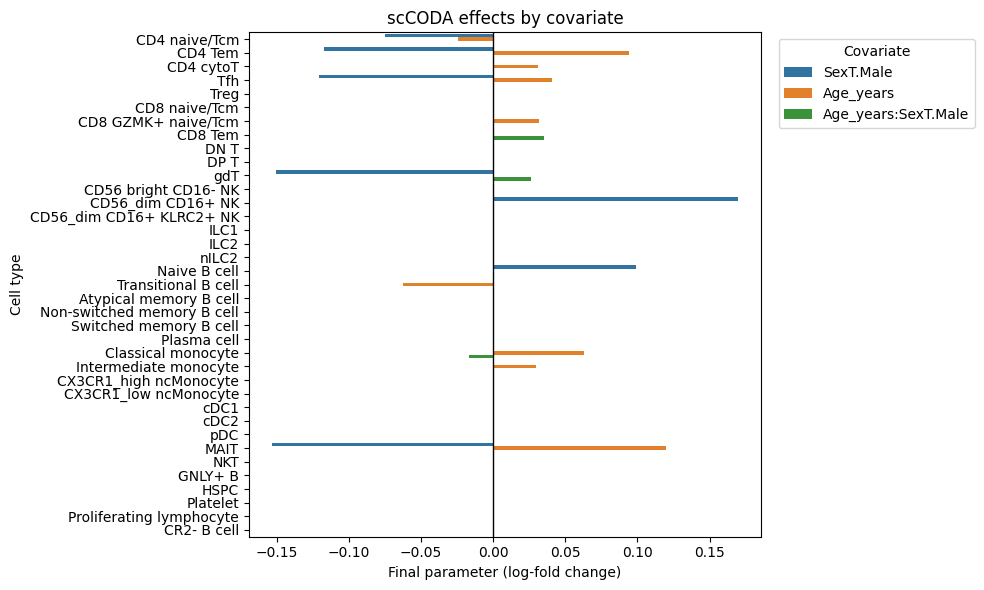

In [108]:
# effect barplot 
plt.figure(figsize=(10, 6))

sns.barplot(
    data=effects_full_plot,
    y="Cell Type",
    x="Final Parameter",
    hue="Covariate",
    orient="h"
)

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Final parameter (log-fold change)")
plt.ylabel("Cell type")
plt.title("scCODA effects by covariate")
plt.legend(title="Covariate", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

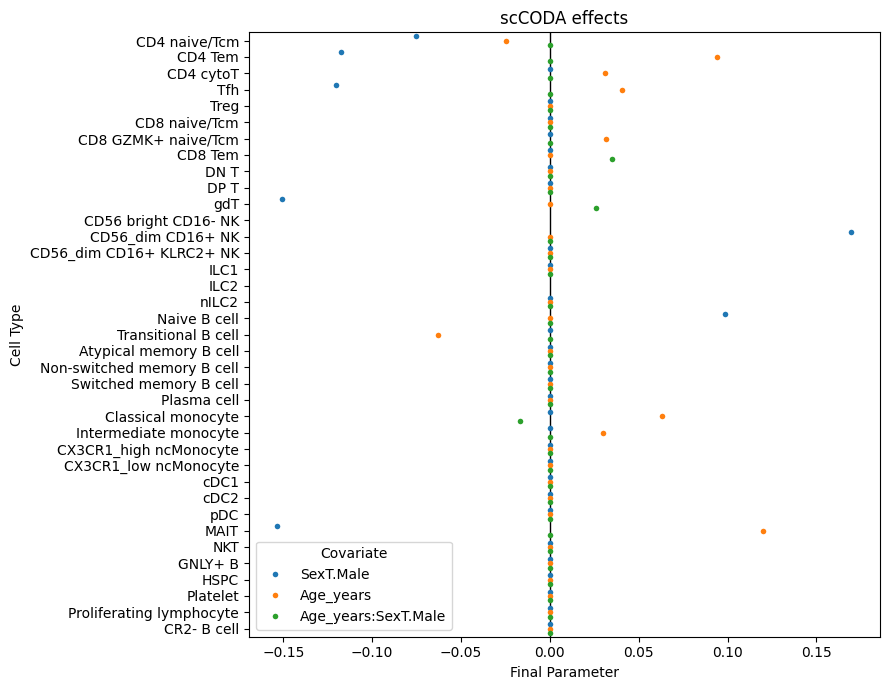

In [107]:
plt.figure(figsize=(9, 7))
sns.stripplot(
    data=effects_full_plot,
    y="Cell Type",
    x="Final Parameter",
    hue="Covariate",
    dodge=True,
    orient="h",
    size=4
)
plt.axvline(0, color="black", linewidth=1)
plt.title("scCODA effects")
plt.tight_layout()
plt.show()

In [88]:
ordered_present = [ct for ct in cell_type_order if ct in beta_auto.index]

lineage_breaks = []
last_group = None
for i, ct in enumerate(ordered_present):
    grp = lineage_map.get(ct, "Other")
    if last_group is not None and grp != last_group:
        lineage_breaks.append(i)
    last_group = grp

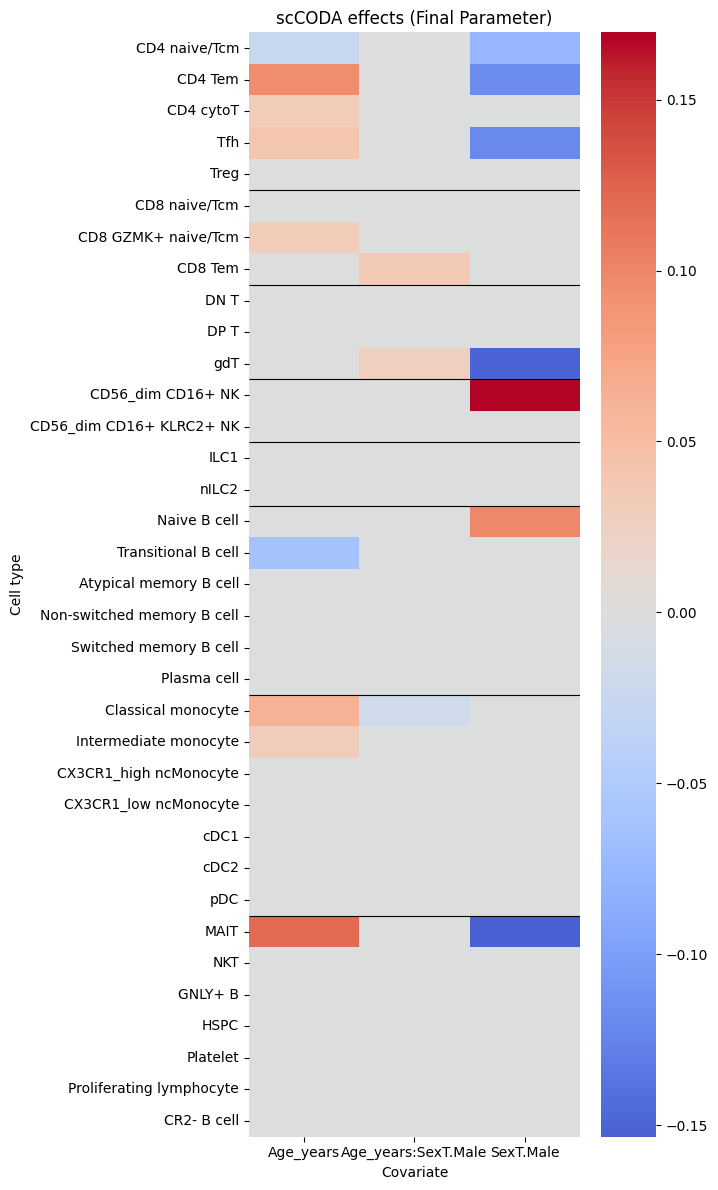

In [113]:
beta_auto = (
    effects_full_plot
    .pivot(index="Cell Type", columns="Covariate", values="Final Parameter")
    .reindex(cell_type_order)
    .dropna(how="all")
)

plt.figure(figsize=(7, 12))
ax = sns.heatmap(beta_auto, cmap="coolwarm", center=0)

for b in lineage_breaks:
    ax.hlines(b, *ax.get_xlim(), colors="black", linewidth=0.8)

plt.title("scCODA effects (Final Parameter)")
plt.xlabel("Covariate")
plt.ylabel("Cell type")
plt.tight_layout()
plt.show()

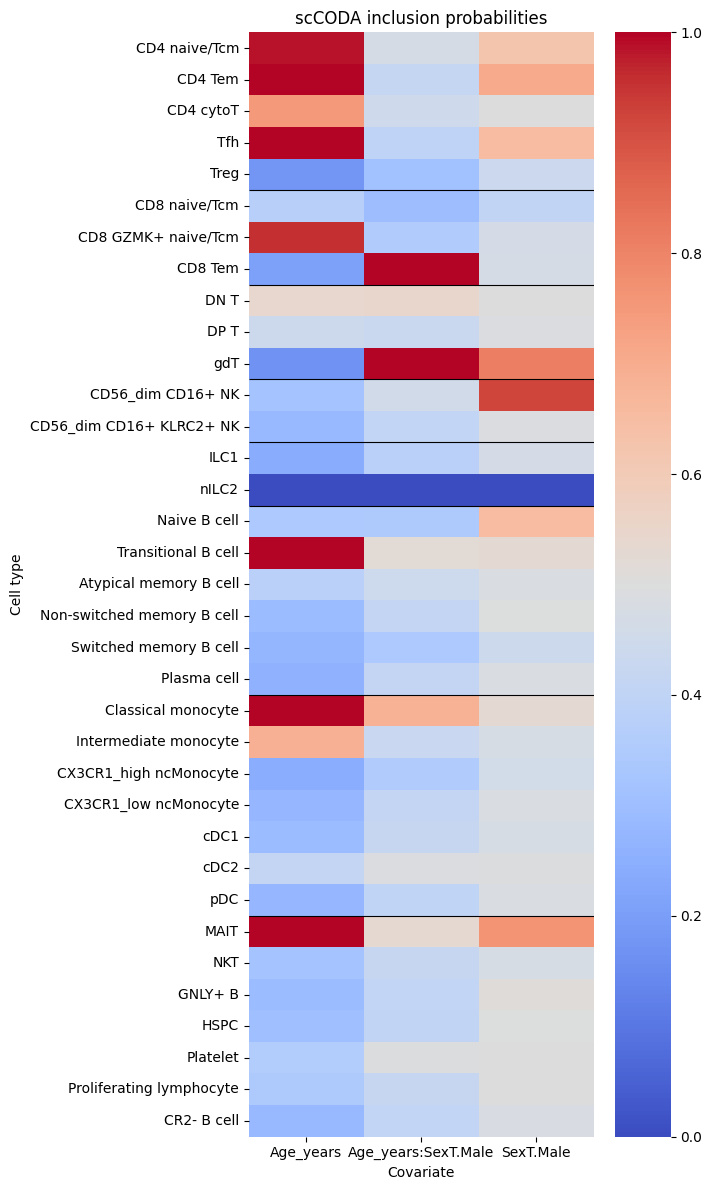

: 

In [ ]:
ip_auto = (
    effects_full_plot
    .pivot(index="Cell Type", columns="Covariate", values="Inclusion probability")
    .reindex(cell_type_order)
    .dropna(how="all")
)

plt.figure(figsize=(7, 12))
ax = sns.heatmap(ip_auto, cmap="coolwarm", vmin=0, vmax=1)

for b in lineage_breaks:
    ax.hlines(b, *ax.get_xlim(), colors="black", linewidth=0.8)

plt.title("scCODA inclusion probabilities")
plt.xlabel("Covariate")
plt.ylabel("Cell type")
plt.tight_layout()
plt.show()